In [1]:
%pip install -r requirements.txt --user

Note: you may need to restart the kernel to use updated packages.


In [2]:
from geoai.download import (
    download_naip,
    download_overture_buildings,
    extract_building_stats,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import rasterio
from pyproj import Transformer
from shapely.geometry import box
import rasterio.windows
from rasterio.windows import Window
from rasterio.transform import xy

In [3]:
bbox_wgs84 = (-120.1018846, 38.99274873, -120.0899834, 39.0020357)

downloaded_files = download_naip(
    bbox=bbox_wgs84,
    output_dir="task_naip_data",
    max_items=1
)

Found 1 NAIP items.
Skipping existing file: task_naip_data/m_3912064_sw_10_060_20220721.tif


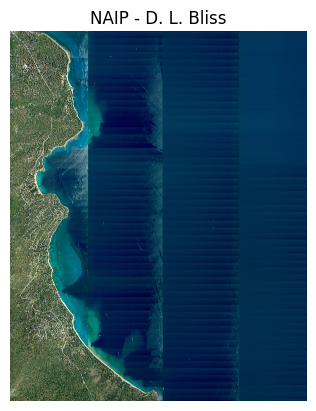

In [4]:
sat_fp = Path("task_naip_data") / "m_3912064_sw_10_060_20220721.tif"

with rasterio.open(sat_fp) as src:
    scale = 1
    preview = src.read(
        indexes=[1,2,3], 
        out_shape=(3, src.height // scale, src.width // scale),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype(np.float32)
    nir = src.read(
        indexes=[4], 
        out_shape=(1, src.height // scale, src.width // scale),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype(np.float32)

rgb = np.transpose(preview, (1,2,0))
nir = np.transpose(nir, (1,2,0))

plt.imshow(np.clip(rgb / (np.nanmax(rgb) + 1e-12), 0, 1))
plt.title("NAIP - D. L. Bliss")
plt.axis("off")
plt.show()

# NDVI  
greenness

In [5]:
def get_ndvi(red: np.ndarray, nir: np.ndarray):
    red, nir = red.astype(float), nir.astype(float)

    with np.errstate(divide='ignore', invalid='ignore'):
        ndvi = (nir - red)/(nir + red)
        ndvi = np.nan_to_num(ndvi)

    return ndvi

red, nir = rgb[:,:,0:1], nir
print(red.shape, nir.shape)
ndvi = get_ndvi(red, nir)
print(ndvi.shape)

(12520, 10060, 1) (12520, 10060, 1)
(12520, 10060, 1)


# Gray Level Co-occurrence Matrix  
neighboring pixel correlations

In [6]:
from skimage.feature import graycomatrix, graycoprops
def get_glcm(image_2d, distances, angles):
    lo, hi = image_2d.min(), image_2d.max()
    if lo == hi: 
        binned_patch = np.zeros_like(image_2d)
    else: 
        binned_patch = (255 * (image_2d - lo) / (hi - lo)).astype(np.uint8)
    
    glcm = graycomatrix(binned_patch, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    return glcm


distances, angles = [1], [0]
glcm = get_glcm(nir.squeeze(), distances, angles)
print(glcm.shape)
contrast = graycoprops(glcm, "contrast")
print(contrast)
correlation = graycoprops(glcm, "correlation")
print(correlation)

(256, 256, 1, 1)
[[109.50155065]]
[[0.98497604]]


In [8]:
glcm.min(), glcm.max()

(np.float64(0.0), np.float64(0.6908373344869106))

(256, 256)


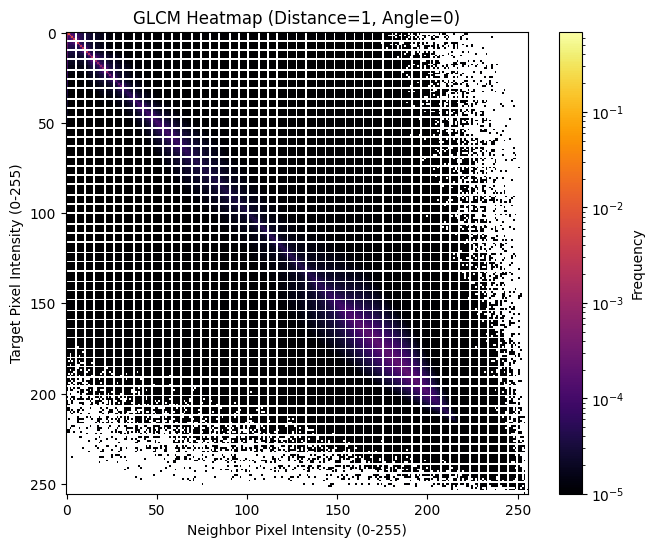

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Assuming 'glcm' is the output from the graycomatrix() function we ran earlier
# The raw output is 4D: (levels, levels, distances, angles)
# We need to slice it to get the 2D matrix for our first distance and angle
glcm_2d = glcm.squeeze()
print(glcm_2d.shape)

# Plotting the matrix as an image/heatmap
plt.figure(figsize=(8, 6))
# We use a logarithmic scale because GLCM values can have huge spikes 
# which makes the rest of the matrix hard to see otherwise
plt.imshow(glcm_2d, cmap='inferno', interpolation='nearest', norm=LogNorm(vmin=1e-5, vmax=glcm_2d.max() + 1e-5)) 

plt.title('GLCM Heatmap (Distance=1, Angle=0)')
plt.xlabel('Neighbor Pixel Intensity (0-255)')
plt.ylabel('Target Pixel Intensity (0-255)')
plt.colorbar(label='Frequency')
plt.show()

# Sobel Filter
neighbor differencing

In [10]:
from skimage.filters import sobel

edge_magnitude = sobel(rgb)
print(edge_magnitude.shape)
bw_edges = edge_magnitude.mean(axis=2).squeeze()
print(bw_edges.shape)

(12520, 10060, 3)
(12520, 10060)


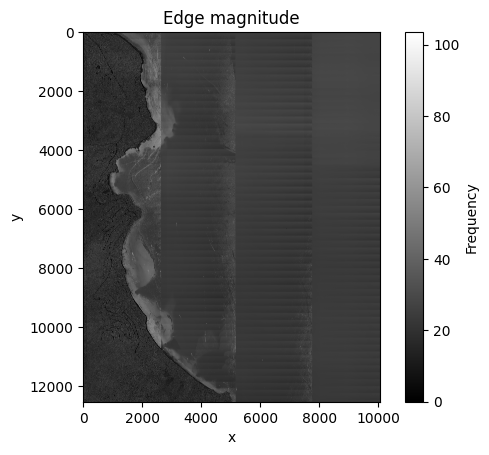

In [11]:
plt.imshow(bw_edges, cmap="gray") 
plt.title('Edge magnitude')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Frequency')
plt.show()

# Gabor Filtering
angled averaging

In [12]:
from skimage.filters import gabor

frequency, theta = 2, np.pi/4
gabor_real, gabor_im = gabor(nir.squeeze(), frequency=frequency, theta=theta)

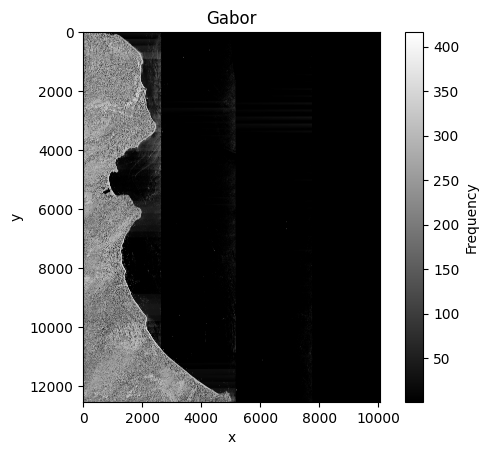

In [13]:
plt.imshow(gabor_real, cmap="gray") 
plt.title('Gabor')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Frequency')
plt.show()

# Global Averaging
average similar image patches assuming gaussian noise

In [14]:
%pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from skimage.restoration import denoise_nl_means, estimate_sigma

def get_global_avg(image_2d):
    std_hat = np.mean(estimate_sigma(image_2d, channel_axis=-1))
    denoised = denoise_nl_means(
        image_2d,
        h=1.15 * std_hat,
        fast_mode=True,
        patch_size=7,
        patch_distance = 28
    )
    return denoised

denoised_rgb = get_global_avg(rgb)
print(denoised_rgb.shape)

In [ ]:
plt.imshow(np.clip(denoised_rgb / (np.nanmax(denoised_rgb) + 1e-12), 0, 1))
plt.title("NAIP - D. L. Bliss (denoised)")
plt.axis("off")
plt.show()